In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_activity= pd.read_csv('Customer Flight Activity.csv')
df_history = pd.read_csv('Customer Loyalty History.csv')

In [ ]:
df_activity.info()
df_history.info()

In [ ]:
df_activity.describe()
df_history.describe()


In [ ]:
#EDA
#Número de filas y columnas y nombres
print(f"Filas x Columnas (shape): {df_activity.shape}")
print(f"Filas x Columnas (shape): {df_history.shape}")
print(df_activity.columns.tolist())
print(df_history.columns.tolist())

In [6]:
df_airline = pd.merge(df_activity, df_history, on='Loyalty Number', how='inner')

In [ ]:
print("\n========== HISTOGRAMAS NUMÉRICOS ==========")

df_airline.hist(bins=20, figsize=(25,25))
plt.show()

In [ ]:
#LIMPIEZA DE DATOS

In [8]:
#NULOS
tabla_nulos = (df_airline.isnull().sum().reset_index().rename(columns={"index": "columna", 0: "nulos",}))

tabla_nulos["% nulos"] = (tabla_nulos["nulos"] / len(df_airline) * 100).round(2)

tabla_nulos["dtype"] = tabla_nulos["columna"].map(df_airline.dtypes)

In [9]:
tabla_nulos

,columna,nulos,% nulos,dtype
0,Loyalty Number,0,0.00,int64
1,Year,0,0.00,int64
2,Month,0,0.00,int64
3,Flights Booked,0,0.00,int64
4,Flights with Companions,0,0.00,int64
5,Total Flights,0,0.00,int64
6,Distance,0,0.00,int64
7,Points Accumulated,0,0.00,float64
8,Points Redeemed,0,0.00,int64
9,Dollar Cost Points Redeemed,0,0.00,int64


In [10]:
#Puntos acumulados
df_airline['Points Accumulated'] = pd.to_numeric(df_airline['Points Accumulated'], errors='coerce').fillna(0)

In [ ]:
df_airline.head()

In [13]:
#Año y mes de cancelación
df_airline['Cancellation Year'] = df_airline['Cancellation Year'].astype(object)
df_airline['Cancellation Month'] = df_airline['Cancellation Month'].astype(object)

df_airline['Cancellation Year'] = df_airline['Cancellation Year'].fillna('Activo')
df_airline['Cancellation Month'] = df_airline['Cancellation Month'].fillna('Activo')

df_airline['Cancellation Year'] = pd.to_numeric(df_airline['Cancellation Year'], errors='coerce').astype('Int64').astype(object).fillna('Activo')
df_airline['Cancellation Month'] = pd.to_numeric(df_airline['Cancellation Month'], errors='coerce').astype('Int64').astype(object).fillna('Activo')

In [14]:
#Salario
# 1. Asegurar que es numérico y pasar a positivo
df_airline['Salary'] = pd.to_numeric(df_airline['Salary'], errors='coerce').abs()

# 2. Imputar nulos por la mediana de su nivel educativo
df_airline['Salary'] = df_airline.groupby('Education')['Salary'].transform(lambda x: x.fillna(x.median()))

# 3. Si aún quedara algún nulo residual, usar la mediana global
mediana_general = df_airline['Salary'].median()
df_airline['Salary'] = df_airline['Salary'].fillna(mediana_general).astype('int64')

In [15]:
#Duplicados
print("\n========== DUPLICADOS ==========")
if df_airline.duplicated().sum() > 0:
    print(f"Se encontraron {df_airline.duplicated().sum()} filas duplicadas.")
    df_airline.drop_duplicates(inplace=True)
else:
    print("¡No hay filas duplicadas!")

df_airline.to_csv('Customer_Airline_Clean.csv', index=False)


========== DUPLICADOS ==========
Se encontraron 1864 filas duplicadas.


In [16]:
#FASE 2 ANÁLISIS ESTADISTICO
#Variables numéricas claves
cols_num = ['Flights Booked', 'Distance', 'Points Accumulated', 'Salary', 'CLV']
df_airline[cols_num].describe()
df_airline[cols_num].mode().iloc[0]

#Variables categóricas
cols_cat = ['Loyalty Card', 'Education', 'Marital Status', 'Gender']
for col in cols_cat:
    print(f"\n--- Distribución para {col} ---")

    print('Conteo absoluto')
    print (df_airline[col].value_counts())
    print('Porcentaje')
    print(df_airline[col].value_counts(normalize=True) * 100)



--- Distribución para Loyalty Card ---
Conteo absoluto
Loyalty Card
Star      183745
Nova      136883
Aurora     83132
Name: count, dtype: int64
Porcentaje
Loyalty Card
Star      45.508470
Nova      33.902071
Aurora    20.589459
Name: proportion, dtype: float64

--- Distribución para Education ---
Conteo absoluto
Education
Bachelor                252567
College                 102260
High School or Below     18915
Doctor                   17731
Master                   12287
Name: count, dtype: int64
Porcentaje
Education
Bachelor                62.553745
College                 25.326927
High School or Below     4.684714
Doctor                   4.391470
Master                   3.043144
Name: proportion, dtype: float64

--- Distribución para Marital Status ---
Conteo absoluto
Marital Status
Married     234845
Single      108153
Divorced     60762
Name: count, dtype: int64
Porcentaje
Marital Status
Married     58.164504
Single      26.786457
Divorced    15.049039
Name: proportion, dty

In [17]:
#FASE 3 VISUALIZACIÓN
#Gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

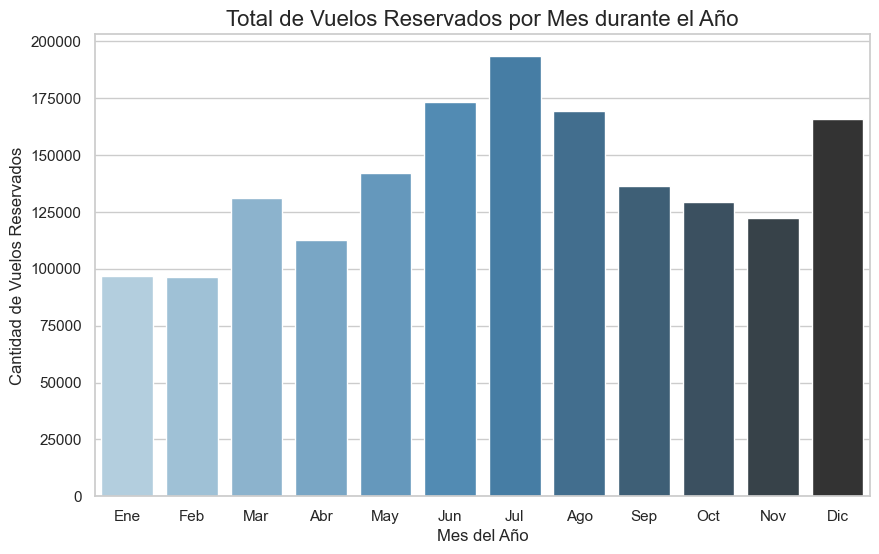

In [18]:
# 1-¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?
# Agrupamos los vuelos por mes y sumamos
vuelos_por_mes = df_airline.groupby('Month')['Flights Booked'].sum().reset_index()
sns.barplot(x='Month', y='Flights Booked', data=vuelos_por_mes, hue='Month', palette='Blues_d', legend=False)
plt.title('Total de Vuelos Reservados por Mes durante el Año')
plt.xlabel('Mes del Año')
plt.ylabel('Cantidad de Vuelos Reservados')
plt.xticks(ticks=range(0, 12), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.show()

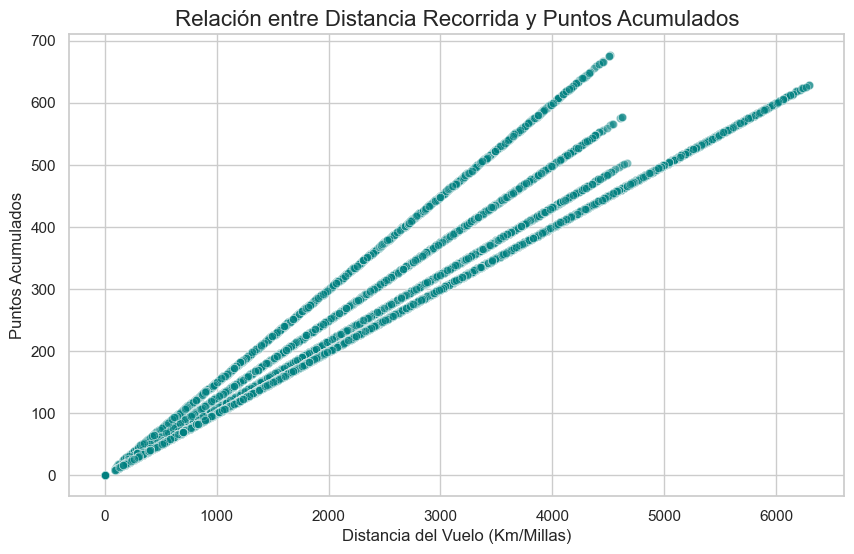

In [19]:
#2-¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?
sns.scatterplot(x='Distance', y='Points Accumulated', data=df_airline, alpha=0.5, color='teal')
plt.title('Relación entre Distancia Recorrida y Puntos Acumulados')
plt.xlabel('Distancia del Vuelo (Km/Millas)')
plt.ylabel('Puntos Acumulados')
plt.show()


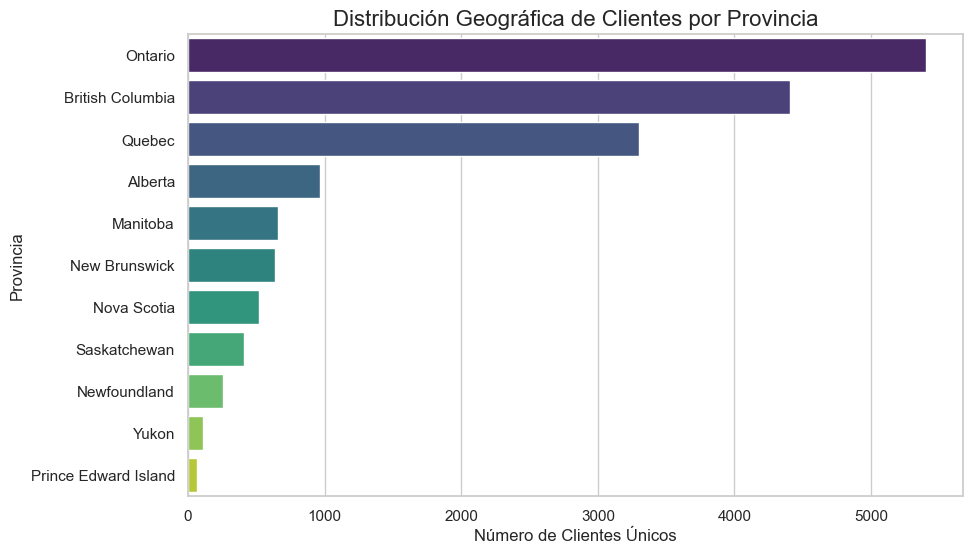

In [20]:
#3- ¿Cuál es la distribución de los clientes por provincia o estado?
#Agrupamos por provincia y número de clientes únicos
clientes_provincia = df_airline.groupby('Province')['Loyalty Number'].nunique().sort_values(ascending=False).reset_index()

sns.barplot(x='Loyalty Number', y='Province', data=clientes_provincia, hue='Province', palette='viridis')
plt.title('Distribución Geográfica de Clientes por Provincia')
plt.xlabel('Número de Clientes Únicos')
plt.ylabel('Provincia')
plt.show()



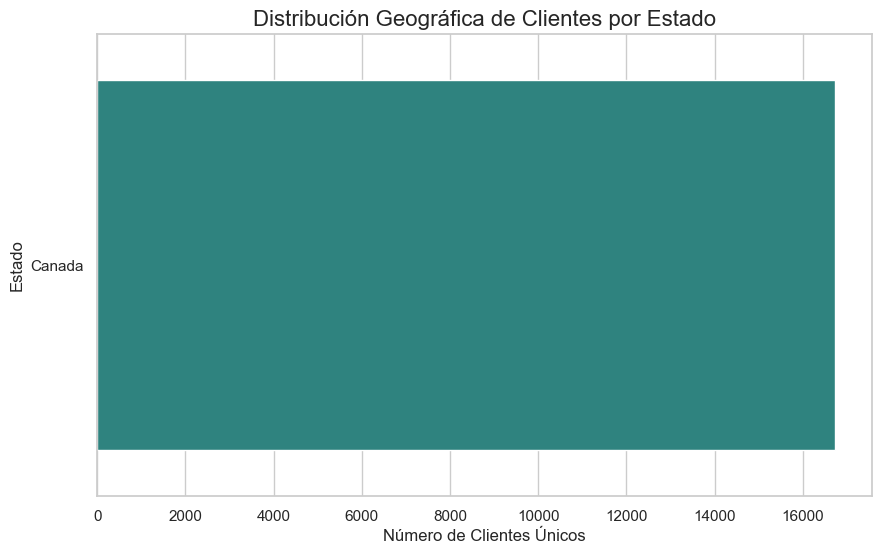

In [ ]:
#Estado
clientes_estado = df_airline.groupby('Country')['Loyalty Number'].nunique().sort_values(ascending=False).reset_index()

sns.barplot(x='Loyalty Number', y='Country', data=clientes_estado, hue='Country', palette='viridis')
plt.title('Distribución Geográfica de Clientes por Estado')
plt.xlabel('Número de Clientes Únicos')
plt.ylabel('Estado')
plt.show()

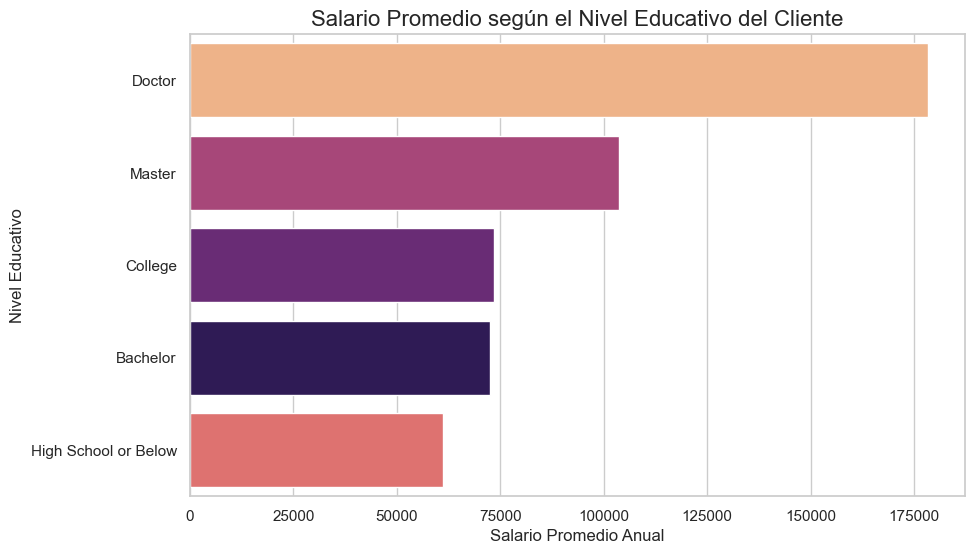

In [23]:
#4- ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?
# Agrupamos por el salario promedio
educacion = df_airline.groupby('Education')['Salary'].mean().sort_values(ascending=False).index

sns.barplot(x='Salary', y='Education', data=df_airline, hue='Education', order=educacion, palette='magma', errorbar=None)
plt.title('Salario Promedio según el Nivel Educativo del Cliente')
plt.xlabel('Salario Promedio Anual')
plt.ylabel('Nivel Educativo')
plt.show()


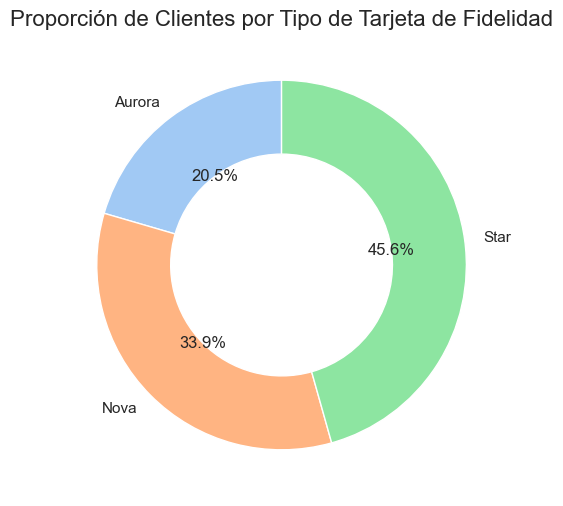

In [24]:

#5-  ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?
# Agrupamos clientes únicos por tipo de tarjeta
tarjetas = df_airline.groupby('Loyalty Card')['Loyalty Number'].nunique()

plt.pie(tarjetas, labels=tarjetas.index, autopct='%1.1f%%', startangle=90, 
        colors=sns.color_palette('pastel')[0:3], wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title('Proporción de Clientes por Tipo de Tarjeta de Fidelidad')
plt.show()



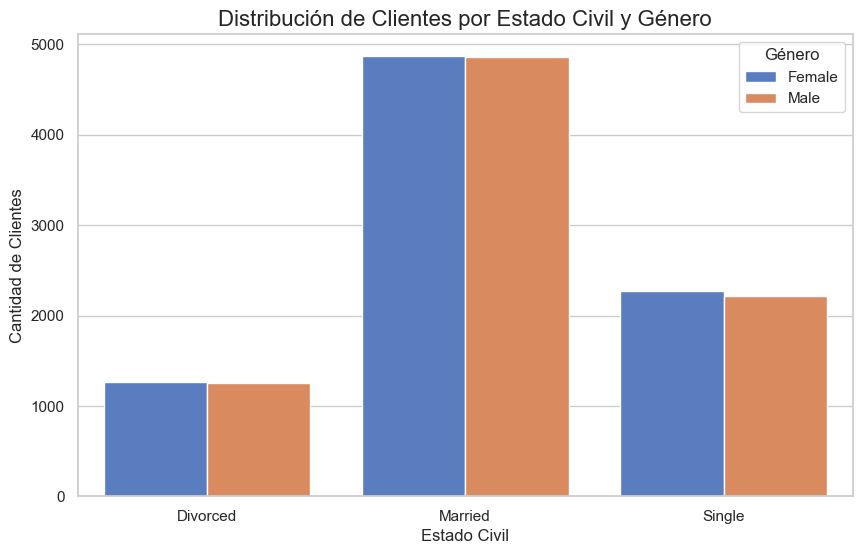

In [25]:
#6- ¿Cómo se distribuyen los clientes según su estado civil y género?
#Agrupamos por estado civil y género
df_civil_genero = df_airline.groupby(['Marital Status', 'Gender'])['Loyalty Number'].nunique().reset_index()

sns.barplot(x='Marital Status', y='Loyalty Number', hue='Gender', data=df_civil_genero, palette='muted')
plt.title('Distribución de Clientes por Estado Civil y Género')
plt.xlabel('Estado Civil')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='Género')
plt.show()

In [26]:
#Fase 4: Evaluación de Diferencias en Reservas de Vuelos por Nivel Educativo
df_diferencias = df_airline[['Flights Booked', 'Education']]
df_diferencias.head()

# Agrupamos por 'Education' y calculamos
analisis_educacion = df_diferencias.groupby('Education')['Flights Booked'].agg(Total_Registros='count',Promedio_Vuelos='mean',Mediana_Vuelos='median',Desviacion_Estandar='std').reset_index()

#Ordenamos
analisis_educacion = analisis_educacion.sort_values(by='Promedio_Vuelos', ascending=False)
print(analisis_educacion)

              Education  Total_Registros  Promedio_Vuelos  Mediana_Vuelos  \
4                Master            12287         4.200700             1.0   
3  High School or Below            18915         4.176209             1.0   
2                Doctor            17731         4.175512             1.0   
1               College           102260         4.169744             1.0   
0              Bachelor           252567         4.110288             1.0   

   Desviacion_Estandar  
4             5.213956  
3             5.239267  
2             5.256971  
1             5.246040  
0             5.221671  


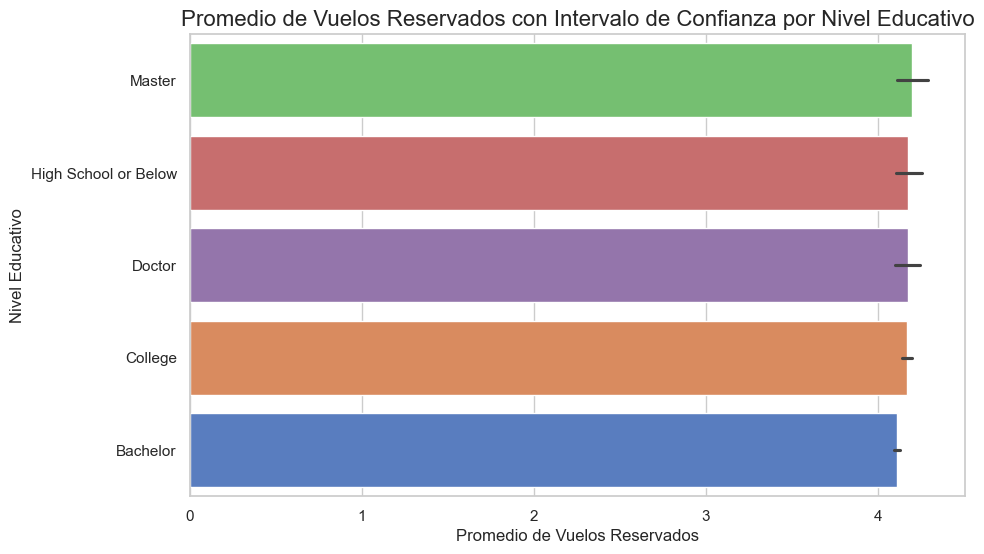

In [27]:
#Gráfica
sns.barplot(x='Flights Booked', y='Education', data=df_diferencias, hue ='Education', order=analisis_educacion['Education'], errorbar='ci', palette='muted')
plt.title('Promedio de Vuelos Reservados con Intervalo de Confianza por Nivel Educativo')
plt.xlabel('Promedio de Vuelos Reservados')
plt.ylabel('Nivel Educativo')
plt.show()